This notebook is a 'scratchpad' of sorts. 
Digested and thought-out thoughts and experiments go into the `experiments/` directory.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
try:
    import marimo as mo
except ModuleNotFoundError:
    mo = None

DATA_PATH = "Data/Data/Gap/gap_data_raw_dorsal_wt_time_series.mat"
SEED = 42
TEST_FRAC = 0.1
BATCH_SIZE = 1024
EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 0.0
LATENT_DIM = 2
HIDDEN_DIMS = [16, 8]
EPS = 1e-8

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"seed={SEED} device={device}")


seed=42 device=mps


# Reading the data

In [2]:
def load_gap_mat(path):
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    file = scipy.io.loadmat(path, simplify_cells=True)
    if "data" not in file:
        raise KeyError("Expected key 'data' in .mat file")
    return file

file = load_gap_mat(DATA_PATH)
data = file["data"]
print(f"Loaded {len(data)} samples")
print(f"Keys: {sorted(list(data[0].keys()))}")

Loaded 292 samples
Keys: ['Gt', 'Hb', 'Kni', 'Kr', 'age', 'dist', 'genotype', 'index', 'orient']


In [3]:
len(file["data"])

292

In [4]:
file["data"][0]

{'index': 1,
 'orient': 1,
 'dist': 32.573461226127016,
 'age': 56.97888721130548,
 'genotype': 1,
 'Kni': array([         nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan, 527.33333333, 536.33333333, 516.33333333,
        508.53333333, 498.77272727, 501.525     , 504.43137255,
        506.48412698, 507.80921053, 506.26111111, 503.47826087,
        497.98283262, 496.29844961, 492.80851064, 493.47297297,
        492.6097561 , 490.73287671, 488.62116041, 485.95890411,
        485.62939297, 486.15635179, 490.27516779, 491.81118881,
        498.01102941, 500.72932331, 503.89230769, 510.5984252 ,
        517.324     , 529.89545455, 536.58604651, 542.90952381,
        545.6097561 , 542.83870968, 539.12264151, 535.42512077,
        531.591133  , 526.45454545, 521.1761658 , 515.28042328

In [5]:
gene_names = ["Kni", "Kr", "Gt", "Hb"]
ts_l = gene_names

def clean_series(arr):
    series = np.asarray(arr)
    return series[~np.isnan(series)]

per_sample_lengths = []
for row in data:
    lengths = [len(clean_series(row[g])) for g in gene_names]
    per_sample_lengths.append(min(lengths))

T = int(np.min(per_sample_lengths))
N = len(data)
X_seq = np.zeros((N, T, len(gene_names)), dtype=np.float32)
for i, row in enumerate(data):
    for j, g in enumerate(gene_names):
        cleaned = clean_series(row[g])
        X_seq[i, :, j] = cleaned[:T]

X_seq = torch.from_numpy(X_seq)
assert not torch.isnan(X_seq).any()
print(f"N={N}, T={T}, X_seq={tuple(X_seq.shape)}")

N=292, T=958, X_seq=(292, 958, 4)


In [6]:
X_seq.shape

torch.Size([292, 958, 4])

In [7]:
# X_seq is (N, T, 4) with computed T

In [8]:
# torch imports and config are defined above

In [9]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=4, latent_dim=2, hidden_dims=None):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [16, 8]
        encoder_layers = []
        in_dim = input_dim
        for h in hidden_dims:
            encoder_layers.append(nn.Linear(in_dim, h))
            encoder_layers.append(nn.ReLU())
            in_dim = h
        encoder_layers.append(nn.Linear(in_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        decoder_layers = []
        in_dim = latent_dim
        for h in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(in_dim, h))
            decoder_layers.append(nn.ReLU())
            in_dim = h
        decoder_layers.append(nn.Linear(in_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        return self.decode(self.encode(x))


In [10]:
X_seq.shape

torch.Size([292, 958, 4])

# Reproducing figure
Fig.1C - making sure I'm correctly reading the dataset; The figure below looks very similar.

In [11]:
sample_index = 3

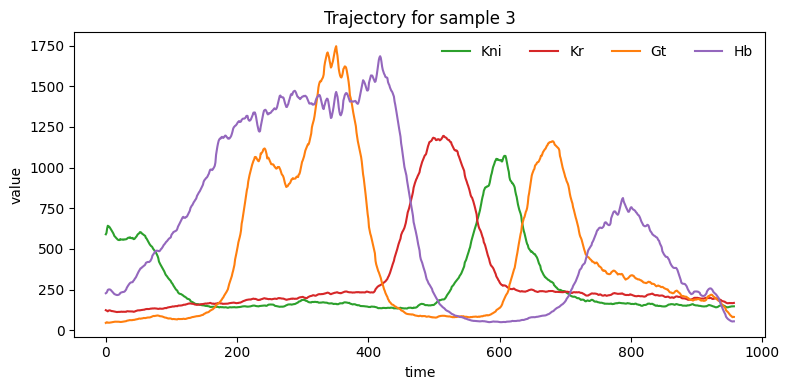

In [12]:
trajectory = X_seq[sample_index].cpu().numpy()
time = np.arange(trajectory.shape[0])
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tab:green", "tab:red","tab:orange",  "tab:purple" ]

for idx, color in enumerate(colors):
    ax.plot(time, trajectory[:, idx], lw=1.5, color=color, label=gene_names[idx])
ax.set_xlabel("time")
ax.set_ylabel("value")
ax.set_title(f"Trajectory for sample {sample_index}")
ax.legend(ncol=4, frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


## Train/test split and normalization
Train-only min-max normalization applied to both train and test.

In [13]:
X_seq = X_seq.float()
print("Raw per-gene stats")
for i, g in enumerate(gene_names):
    vals = X_seq[..., i]
    print(f"{g:>4s} min={vals.min().item():.3f} max={vals.max().item():.3f} mean={vals.mean().item():.3f} std={vals.std().item():.3f}")

Raw per-gene stats
 Kni min=71.333 max=1440.058 mean=242.545 std=191.520
  Kr min=40.500 max=1391.937 mean=240.275 std=186.024
  Gt min=22.800 max=2525.936 mean=428.819 std=470.656
  Hb min=19.870 max=2783.198 mean=600.492 std=577.263


In [14]:
def split_indices(n, test_frac, seed):
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g)
    test_size = int(n * test_frac)
    test_idx = perm[:test_size]
    train_idx = perm[test_size:]
    return train_idx, test_idx

train_idx, test_idx = split_indices(N, TEST_FRAC, SEED)
print(f"train={len(train_idx)} test={len(test_idx)}")
print(f"overlap={len(set(train_idx.tolist()).intersection(set(test_idx.tolist())))}")


train=263 test=29
overlap=0


Normalized data is now split by sample and scaled using train-only stats.

In [15]:
X_train_seq = X_seq[train_idx]
X_test_seq = X_seq[test_idx]

train_min = X_train_seq.reshape(-1, len(gene_names)).min(0).values
train_max = X_train_seq.reshape(-1, len(gene_names)).max(0).values
scale = (train_max - train_min) + EPS

X_train_seq_n = (X_train_seq - train_min) / scale
X_test_seq_n = (X_test_seq - train_min) / scale

train_flat = X_train_seq_n.reshape(-1, len(gene_names))
print("Train normalized stats (min-max)")
for i, g in enumerate(gene_names):
    vals = train_flat[:, i]
    print(f"{g:>4s} min={vals.min().item():.3f} max={vals.max().item():.3f}")
print("Any NaNs:", torch.isnan(X_train_seq_n).any().item(), torch.isnan(X_test_seq_n).any().item())


Train normalized stats (min-max)
 Kni min=0.000 max=1.000
  Kr min=0.000 max=1.000
  Gt min=0.000 max=1.000
  Hb min=0.000 max=1.000


Any NaNs: False False


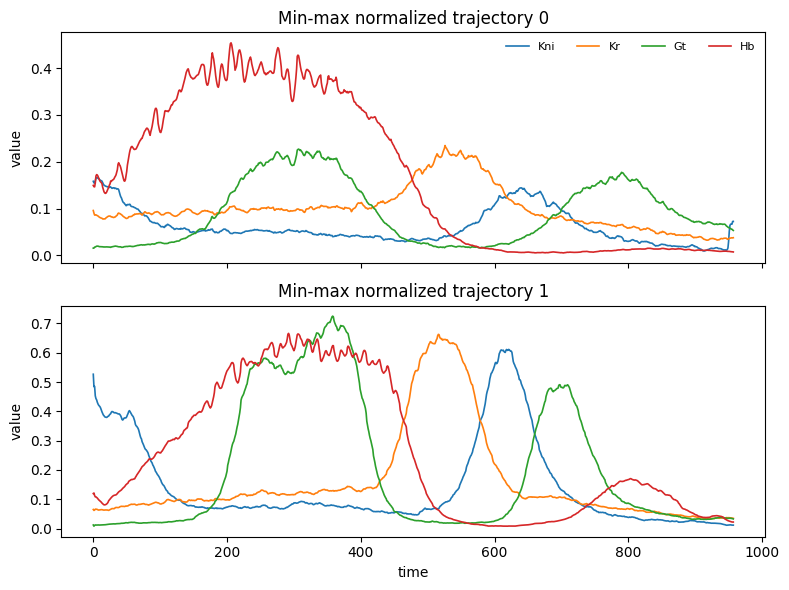

In [16]:
# plot min-max normalized trajectories (example)
n_samples = min(2, X_train_seq_n.shape[0])
T = X_train_seq_n.shape[1]
time = np.arange(T)
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, ax = plt.subplots(n_samples, figsize=(8, 3 * n_samples), sharex=True)
if n_samples == 1:
    ax = [ax]

for i in range(n_samples):
    traj = X_train_seq_n[i].cpu().numpy()
    for g_idx, g in enumerate(gene_names):
        ax[i].plot(time, traj[:, g_idx], lw=1.2, color=colors[g_idx], label=g)
    ax[i].set_title(f"Min-max normalized trajectory {i}")
    ax[i].set_ylabel("value")
    if i == 0:
        ax[i].legend(ncol=4, frameon=False, fontsize=8)

ax[-1].set_xlabel("time")
plt.tight_layout()
plt.show()


# Flattened training view

In [17]:
X_train_flat = X_train_seq_n.reshape(-1, len(gene_names))
X_test_flat = X_test_seq_n.reshape(-1, len(gene_names))
print(f"X_train_flat: {tuple(X_train_flat.shape)} X_test_flat: {tuple(X_test_flat.shape)}")

X_train_flat: (251954, 4) X_test_flat: (27782, 4)


# Model
Training a standard autoencoder purely on cell states (no trajectory information)

In [18]:
train_dataset = TensorDataset(X_train_flat)
train_gen = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=train_gen)
print(f"train_flat={tuple(X_train_flat.shape)} test_flat={tuple(X_test_flat.shape)}")


train_flat=(251954, 4) test_flat=(27782, 4)


In [19]:
print("NaNs in train:", torch.isnan(X_train_flat).any().item())
print("NaNs in test :", torch.isnan(X_test_flat).any().item())

NaNs in train: False
NaNs in test : False


epoch 0, train=0.035655 test=0.025339


epoch 1, train=0.015925 test=0.007399


epoch 2, train=0.005639 test=0.002762


epoch 3, train=0.002023 test=0.001129


epoch 4, train=0.001171 test=0.000954


...

epoch 45, train=0.000392 test=0.000358


epoch 46, train=0.000391 test=0.000355


epoch 47, train=0.000389 test=0.000367


epoch 48, train=0.000389 test=0.000344


epoch 49, train=0.000384 test=0.000340


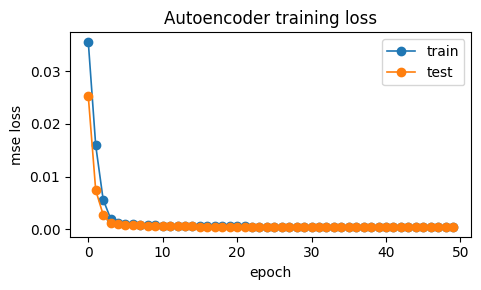

In [20]:
model = Autoencoder(input_dim=len(gene_names), latent_dim=LATENT_DIM, hidden_dims=HIDDEN_DIMS).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()

train_loss_history = []
test_loss_history = []
X_test_flat_device = X_test_flat.to(device)

for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        running += loss.item() * batch.size(0)
    train_loss = running / len(X_train_flat)
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_flat_device), X_test_flat_device).item()
    train_loss_history.append(train_loss)
    test_loss_history.append(test_loss)
    print(f"epoch {epoch}, train={train_loss:.6f} test={test_loss:.6f}")

plt.figure(figsize=(5, 3))
plt.plot(train_loss_history, marker="o", lw=1.2, label="train")
plt.plot(test_loss_history, marker="o", lw=1.2, label="test")
plt.xlabel("epoch")
plt.ylabel("mse loss")
plt.title("Autoencoder training loss")
plt.legend()
plt.tight_layout()
plt.show()


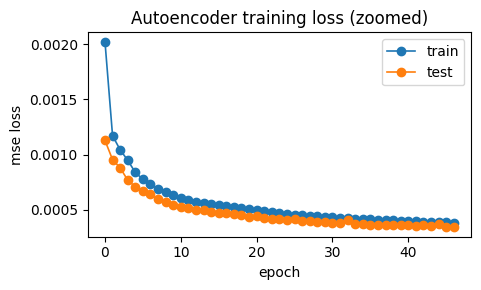

In [21]:
plt.figure(figsize=(5, 3))
plt.plot(train_loss_history[3:], marker="o", lw=1.2, label="train")
plt.plot(test_loss_history[3:], marker="o", lw=1.2, label="test")
plt.xlabel("epoch")
plt.ylabel("mse loss")
plt.title("Autoencoder training loss (zoomed)")
plt.legend()
plt.tight_layout()
plt.show()

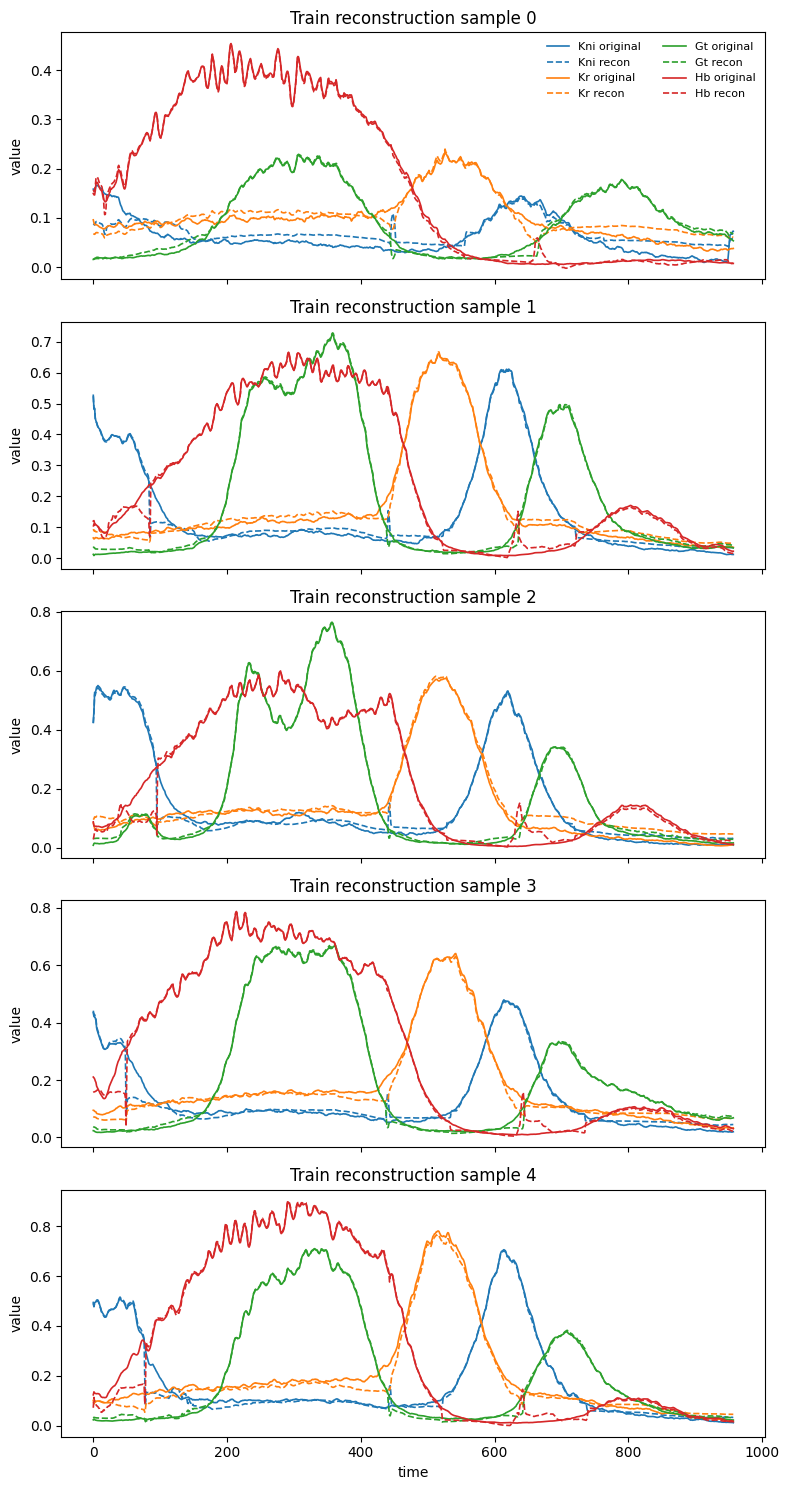

In [22]:
def plot_recon_samples(model, X_seq, gene_names, n=5, title_prefix="Train"):
    model.eval()
    n = min(n, X_seq.shape[0])
    T = X_seq.shape[1]
    time = np.arange(T)
    fig, ax = plt.subplots(n, figsize=(8, 3 * n), sharex=True)
    if n == 1:
        ax = [ax]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    with torch.no_grad():
        for i in range(n):
            sample = X_seq[i].to(device)
            recon = model(sample).cpu().numpy()
            sample_np = sample.cpu().numpy()
            for idx, color in enumerate(colors):
                ax[i].plot(time, sample_np[:, idx], color=color, lw=1.2, label=f"{gene_names[idx]} original")
                ax[i].plot(time, recon[:, idx], color=color, lw=1.2, ls="--", label=f"{gene_names[idx]} recon")
            ax[i].set_ylabel("value")
            ax[i].set_title(f"{title_prefix} reconstruction sample {i}")
    ax[-1].set_xlabel("time")
    ax[0].legend(ncol=2, frameon=False, fontsize=8)
    fig.tight_layout()
    plt.show()

plot_recon_samples(model, X_train_seq_n, gene_names, n=5, title_prefix="Train")

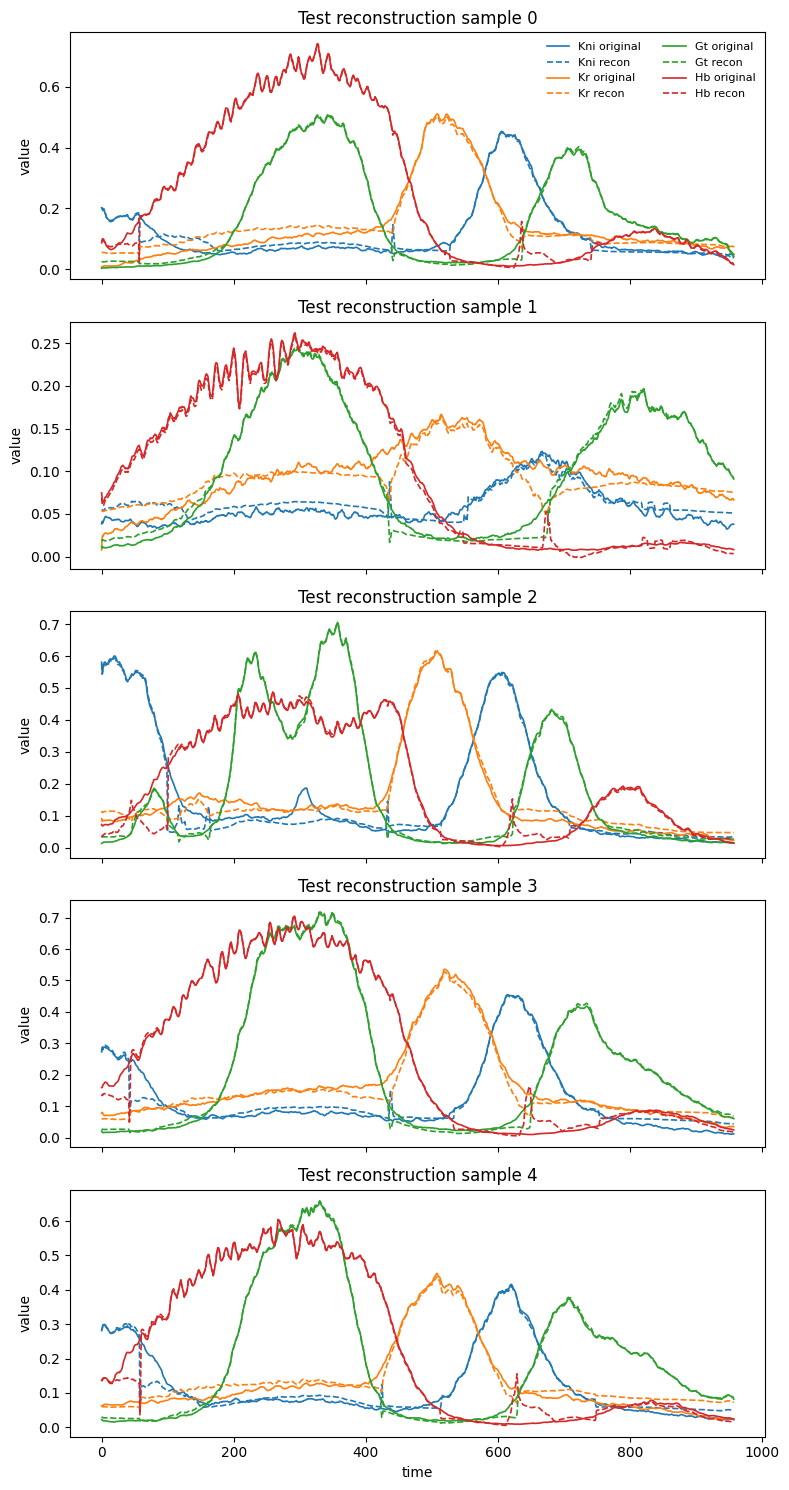

In [23]:
plot_recon_samples(model, X_test_seq_n, gene_names, n=min(5, X_test_seq_n.shape[0]), title_prefix="Test")

loss train: 0.0003843432932626456 loss test: 0.00033982322202064097


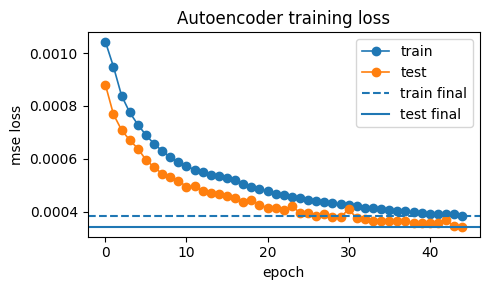

In [24]:
model.eval()
with torch.no_grad():
  train_loss = criterion(model(X_train_flat.to(device)), X_train_flat.to(device)).item()
  test_loss = criterion(model(X_test_flat.to(device)), X_test_flat.to(device)).item()
  print('loss train:', train_loss, 'loss test:', test_loss)

  plt.figure(figsize=(5, 3))
  plt.plot(train_loss_history[5:], marker="o", lw=1.2, label='train')
  plt.plot(test_loss_history[5:], marker="o", lw=1.2, label='test')
  plt.axhline(train_loss, linestyle='--', label='train final')
  plt.axhline(test_loss, linestyle='-', label='test final')
  plt.xlabel("epoch")
  plt.ylabel("mse loss")
  plt.title("Autoencoder training loss")
  plt.tight_layout()
  plt.legend()
  plt.show()



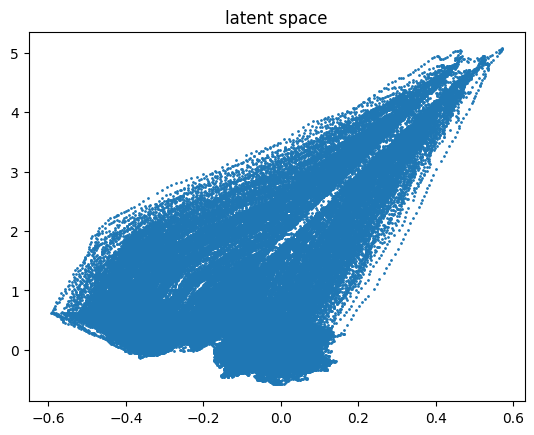

In [25]:
# inspecting latent space
model.eval()
with torch.no_grad():
  z = model.encode(X_train_flat.to(device)).cpu().numpy()
plt.scatter(z[:, 0], z[:, 1], s=1)
plt.title('latent space')
plt.show()


In [26]:
X_train_flat.shape

torch.Size([251954, 4])

In [27]:
def per_gene_mse(model, X_flat, gene_names):
    model.eval()
    with torch.no_grad():
        x = X_flat.to(device)
        recon = model(x)
        errors = (recon - x) ** 2
        per_gene = errors.mean(dim=0)
        total = per_gene.sum()
        frac = per_gene / total
    return per_gene.cpu(), frac.cpu()

for split_name, X_flat in [("train", X_train_flat), ("test", X_test_flat)]:
    per_gene, frac = per_gene_mse(model, X_flat, gene_names)
    print(f"Per-gene MSE ({split_name}):")
    for g, mse, f in zip(gene_names, per_gene, frac):
        print(f"{g:>4s}  MSE={mse.item():.6f}   frac={100*f.item():6.2f}%")

Per-gene MSE (train):
 Kni  MSE=0.000491   frac= 31.94%
  Kr  MSE=0.000530   frac= 34.46%
  Gt  MSE=0.000093   frac=  6.04%
  Hb  MSE=0.000424   frac= 27.56%
Per-gene MSE (test):
 Kni  MSE=0.000418   frac= 30.78%
  Kr  MSE=0.000505   frac= 37.14%
  Gt  MSE=0.000097   frac=  7.11%
  Hb  MSE=0.000339   frac= 24.97%


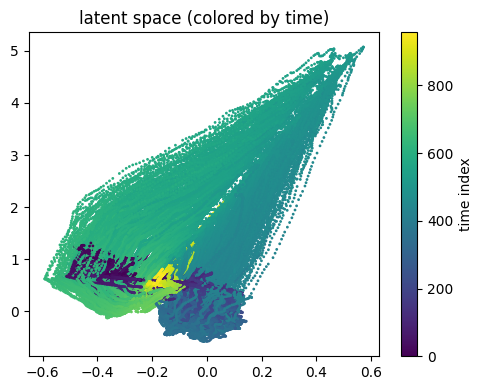

In [28]:
# latent space colored by time index
model.eval()
with torch.no_grad():
    z_latent = model.encode(X_train_flat.to(device)).cpu().numpy()

T = X_train_seq_n.shape[1]
n_traj = X_train_seq_n.shape[0]
time_idx = np.tile(np.arange(T), n_traj)

plt.figure(figsize=(5, 4))
plt.scatter(z_latent[:, 0], z_latent[:, 1], c=time_idx, s=1, cmap="viridis")
plt.colorbar(label="time index")
plt.title("latent space (colored by time)")
plt.tight_layout()
plt.show()


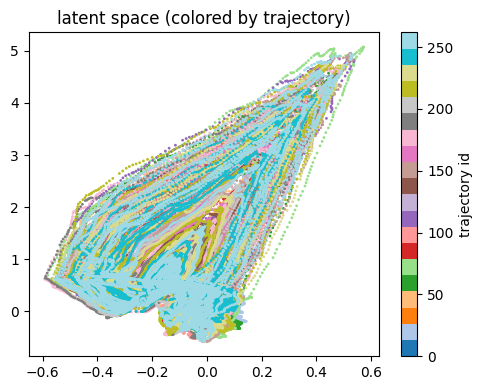

In [29]:
# latent space colored by trajectory id
if "z_latent" not in globals():
    model.eval()
    with torch.no_grad():
        z_latent = model.encode(X_train_flat.to(device)).cpu().numpy()

T = X_train_seq_n.shape[1]
n_traj = X_train_seq_n.shape[0]
traj_idx = np.repeat(np.arange(n_traj), T)

plt.figure(figsize=(5, 4))
plt.scatter(z_latent[:, 0], z_latent[:, 1], c=traj_idx, s=1, cmap="tab20")
plt.colorbar(label="trajectory id")
plt.title("latent space (colored by trajectory)")
plt.tight_layout()
plt.show()


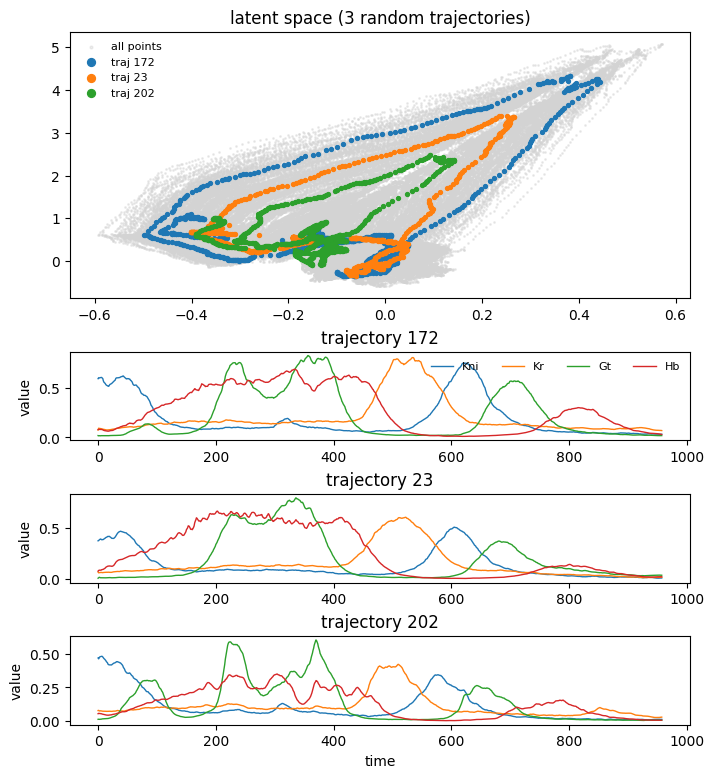

In [30]:
# latent space: gray background + 3 random trajectories
if "z_latent" not in globals():
    model.eval()
    with torch.no_grad():
        z_latent = model.encode(X_train_flat.to(device)).cpu().numpy()

T = X_train_seq_n.shape[1]
n_traj = X_train_seq_n.shape[0]
traj_idx = np.repeat(np.arange(n_traj), T)

rng = np.random.default_rng(SEED)
sel = rng.choice(n_traj, size=min(3, n_traj), replace=False)
colors = ["tab:blue", "tab:orange", "tab:green"]

fig = plt.figure(figsize=(8, 9))
gs = fig.add_gridspec(4, 1, height_ratios=[3, 1, 1, 1], hspace=0.4)
ax0 = fig.add_subplot(gs[0, 0])
ax_ts = [fig.add_subplot(gs[i, 0]) for i in range(1, 4)]

ax0.scatter(z_latent[:, 0], z_latent[:, 1], s=1, c="lightgray", alpha=0.4, label="all points")
for i, traj_id in enumerate(sel):
    mask = traj_idx == traj_id
    ax0.scatter(z_latent[mask, 0], z_latent[mask, 1], s=8, color=colors[i], label=f"traj {traj_id}")

ax0.set_title("latent space (3 random trajectories)")
ax0.legend(markerscale=2, frameon=False, fontsize=8)

T = X_train_seq_n.shape[1]
time = np.arange(T)
for i, traj_id in enumerate(sel):
    traj = X_train_seq_n[traj_id].cpu().numpy()
    for g_idx, g in enumerate(gene_names):
        ax_ts[i].plot(time, traj[:, g_idx], lw=1.0, label=g)
    ax_ts[i].set_title(f"trajectory {traj_id}")
    ax_ts[i].set_ylabel("value")
    if i == 0:
        ax_ts[i].legend(ncol=4, frameon=False, fontsize=8)

ax_ts[-1].set_xlabel("time")
plt.show()


In [31]:
# animate one selected trajectory across time
traj_pick = 0  # index into sel (0..len(sel)-1)
traj_id = int(sel[traj_pick])
mask = traj_idx == traj_id
z_traj = z_latent[mask]
traj = X_train_seq_n[traj_id].cpu().numpy()
time = np.arange(traj.shape[0])

import matplotlib.animation as animation
import matplotlib as mpl
from IPython.display import HTML

fig_anim = plt.figure(figsize=(6, 7))
gs_anim = fig_anim.add_gridspec(2, 1, height_ratios=[3, 2], hspace=0.35)
ax_latent = fig_anim.add_subplot(gs_anim[0, 0])
ax_ts = fig_anim.add_subplot(gs_anim[1, 0])

ax_latent.scatter(z_latent[:, 0], z_latent[:, 1], s=2, c="lightgray", alpha=0.3)
path_line, = ax_latent.plot([], [], color=colors[traj_pick], lw=1.5, alpha=0.9)
point, = ax_latent.plot([], [], marker="o", color=colors[traj_pick], markersize=6)

pad = 0.05
x_min, x_max = z_latent[:, 0].min(), z_latent[:, 0].max()
y_min, y_max = z_latent[:, 1].min(), z_latent[:, 1].max()
ax_latent.set_xlim(x_min - pad, x_max + pad)
ax_latent.set_ylim(y_min - pad, y_max + pad)
ax_latent.set_title(f"latent space (trajectory {traj_id})")
ax_latent.set_xlabel("z1")
ax_latent.set_ylabel("z2")

ts_lines = []
for g_idx, g in enumerate(gene_names):
    line, = ax_ts.plot([], [], lw=1.2, label=g)
    ts_lines.append(line)
time_marker = ax_ts.axvline(0, color="black", lw=0.8, alpha=0.5)

y_min, y_max = traj.min(), traj.max()
y_pad = 0.05 * (y_max - y_min + 1e-6)
ax_ts.set_xlim(time.min(), time.max())
ax_ts.set_ylim(y_min - y_pad, y_max + y_pad)
ax_ts.set_title(f"trajectory {traj_id} (time series)")
ax_ts.set_xlabel("time")
ax_ts.set_ylabel("value")
ax_ts.legend(ncol=4, frameon=False, fontsize=8)

def init():
    path_line.set_data([], [])
    point.set_data([], [])
    for line in ts_lines:
        line.set_data([], [])
    time_marker.set_xdata([time[0], time[0]])
    return [path_line, point, time_marker, *ts_lines]

def update(frame):
    path_line.set_data(z_traj[: frame + 1, 0], z_traj[: frame + 1, 1])
    point.set_data([z_traj[frame, 0]], [z_traj[frame, 1]])
    for g_idx, line in enumerate(ts_lines):
        line.set_data(time[: frame + 1], traj[: frame + 1, g_idx])
    time_marker.set_xdata([time[frame], time[frame]])
    return [path_line, point, time_marker, *ts_lines]

mpl.rcParams["animation.embed_limit"] = 100  # MB

anim = animation.FuncAnimation(
    fig_anim,
    update,
    frames=traj.shape[0],
    init_func=init,
    interval=250,
    blit=True,
)
plt.close(fig_anim)
HTML(anim.to_jshtml(fps=4))


In [97]:
# latent space colored by gene value (2x2)
if "z_latent" not in globals():
    model.eval()
    with torch.no_grad():
        z_latent = model.encode(X_train_flat.to(device)).cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(8, 7), constrained_layout=True)
axes = axes.flatten()

for i, g in enumerate(gene_names):
    gene_vals = X_train_flat[:, i].cpu().numpy()
    sc = axes[i].scatter(z_latent[:, 0], z_latent[:, 1], c=gene_vals, s=1, cmap="magma")
    axes[i].set_title(f"{g} (normalized)")
    fig.colorbar(sc, ax=axes[i])

plt.show()


In [ ]:
# interactive trajectory/frame explorer
import ipywidgets as widgets
from IPython.display import display

model.eval()
with torch.no_grad():
    z_train_flat = model.encode(X_train_flat.to(device)).cpu().numpy()

n_traj, T, n_genes = X_train_seq_n.shape
z_train_seq = z_train_flat.reshape(n_traj, T, -1)

traj_selector = widgets.Dropdown(
    options=[(f"trajectory {i}", i) for i in range(n_traj)],
    value=0,
    description="trajectory:",
)
frame_selector = widgets.IntSlider(
    value=0,
    min=0,
    max=T - 1,
    step=1,
    description="frame:",
    continuous_update=False,
)
gene_selector = widgets.Dropdown(
    options=[(g, i) for i, g in enumerate(gene_names)],
    value=0,
    description="timeseries:",
)
out = widgets.Output()

def _redraw(*_):
    traj_id = traj_selector.value
    t = frame_selector.value
    g = gene_selector.value

    z_traj = z_train_seq[traj_id]
    x_traj = X_train_seq_n[traj_id].cpu().numpy()
    time = np.arange(T)

    with out:
        out.clear_output(wait=True)
        fig, (ax_latent, ax_ts) = plt.subplots(1, 2, figsize=(11, 4))

        if z_traj.shape[1] >= 2:
            ax_latent.plot(z_traj[:, 0], z_traj[:, 1], color="0.6", lw=1.5)
            ax_latent.scatter(z_traj[:, 0], z_traj[:, 1], s=12, color="0.75")
            ax_latent.scatter(z_traj[t, 0], z_traj[t, 1], s=120, color="tab:red", zorder=3)
            ax_latent.set_xlabel("z1")
            ax_latent.set_ylabel("z2")
        else:
            ax_latent.plot(time, z_traj[:, 0], color="0.6", lw=1.5)
            ax_latent.scatter(time, z_traj[:, 0], s=12, color="0.75")
            ax_latent.scatter(time[t], z_traj[t, 0], s=120, color="tab:red", zorder=3)
            ax_latent.set_xlabel("time")
            ax_latent.set_ylabel("z1")

        ax_latent.set_title(f"latent trajectory (trajectory {traj_id})")

        ax_ts.plot(time, x_traj[:, g], lw=2, color="tab:blue")
        ax_ts.axvline(t, color="tab:red", lw=2, ls="--")
        ax_ts.scatter([t], [x_traj[t, g]], color="tab:red", s=60, zorder=3)
        ax_ts.set_title(f"time series: {gene_names[g]}")
        ax_ts.set_xlabel("frame/timepoint")
        ax_ts.set_ylabel("normalized value")

        fig.tight_layout()
        plt.show()

traj_selector.observe(_redraw, names="value")
frame_selector.observe(_redraw, names="value")
gene_selector.observe(_redraw, names="value")

display(widgets.VBox([traj_selector, frame_selector, gene_selector, out]))
_redraw()
